
##### Course :DSC550-T301 Data Mining
##### Assignment: Weeks 4.2 Exercise: Predicting Fuel Efficiency
##### Student : Solomon Kibret


#### Data Path

In [97]:

# ── 2. Data Path ──────────────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\solom\DSC530\envs\book_env\auto-mpg.csv"

import os
if os.path.exists(DATA_PATH):
    print(f"✅ Data file found: {DATA_PATH}")
else:
    print(f"⚠️  File not found at: {DATA_PATH}")
    print("   Please update DATA_PATH above to match your local path.")

✅ Data file found: C:\Users\solom\DSC530\envs\book_env\auto-mpg.csv


In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)

# Load the dataset from the local path defined above
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}  (rows, columns)")
df.head(10)

Dataset shape: (398, 9)  (rows, columns)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [119]:
# Check data types and missing values at a glance
print("Data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

Data types:
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [120]:
# Summary statistics for numeric columns
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


### Step 2 – Prepare the Data for Modeling

### 2a – Remove the `car name` Column

The car name is a free-text identifier unique to each vehicle. It carries no generalizable numeric signal and would cause errors in a regression model, so we drop it.

In [121]:
# Drop car name — it is a text label, not a predictive feature
df.drop(columns=['car name'], inplace=True)

print("Columns remaining:", df.columns.tolist())

Columns remaining: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']


### 2b – Fix the `horsepower` Column

**Why did it import as a string?**  
The raw dataset uses `?` as a placeholder for 6 missing horsepower values. Because `?` is not a number, pandas cannot infer a numeric type and reads the entire column as `object` (string). We must:
1. Identify and show the offending rows.
2. Replace `?` with `NaN`.
3. Impute `NaN` with the column mean.
4. Convert the column to `float`.

In [122]:
# Confirm horsepower came in as string / object
print("horsepower dtype:", df['horsepower'].dtype)

# Identify non-numeric entries
bad_rows = df[~df['horsepower'].str.match(r'^\d*\.?\d+$', na=False)]
print(f"\nRows with '?' in horsepower ({len(bad_rows)} total):")
print(bad_rows[['horsepower']])

horsepower dtype: object

Rows with '?' in horsepower (6 total):
    horsepower
32           ?
126          ?
330          ?
336          ?
354          ?
374          ?


In [123]:
# Replace '?' with NaN and convert to float
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Compute the mean of the non-missing values
hp_mean = df['horsepower'].mean()
print(f"Column mean (ignoring NaN): {hp_mean:.2f} hp")

# Impute NaN with the mean
df['horsepower'] = df['horsepower'].fillna(hp_mean)

# Verify: no more NaNs, correct dtype
print(f"NaN values remaining: {df['horsepower'].isna().sum()}")
print(f"dtype after fix: {df['horsepower'].dtype}")

Column mean (ignoring NaN): 104.47 hp
NaN values remaining: 0
dtype after fix: float64


### 2c – Create Dummy Variables for `origin`

`origin` is coded as integers 1 (USA), 2 (Europe), 3 (Japan). Although numeric, it is **categorical** — there is no meaningful ordering or distance between these values. We one-hot encode it and drop one category (USA) to serve as the reference group and avoid perfect multicollinearity.

In [124]:
# One-hot encode origin; drop_first=True keeps USA as the reference group
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

# Rename for clarity (2 = Europe, 3 = Japan)
df.rename(columns={'origin_2': 'origin_europe', 'origin_3': 'origin_japan'}, inplace=True)

print("Columns after encoding:", df.columns.tolist())
print(f"\nFinal dataset shape: {df.shape}")
df.head()

Columns after encoding: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_europe', 'origin_japan']

Final dataset shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_europe,origin_japan
0,18.0,8,307.0,130.0,3504,12.0,70,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,False,False


## Step 3 – Correlation Analysis

A **Pearson correlation coefficient** ranges from −1 to +1 and measures the strength and direction of the linear relationship between two variables.

In [125]:
# Correlation matrix
corr = df.corr()

# Correlation of every feature with mpg, sorted
mpg_corr = corr['mpg'].drop('mpg').sort_values()
print("Correlation with mpg (sorted):")
print(mpg_corr.to_string())

Correlation with mpg (sorted):
weight          -0.831741
displacement    -0.804203
cylinders       -0.775396
horsepower      -0.771437
origin_europe    0.259022
acceleration     0.420289
origin_japan     0.442174
model year       0.579267


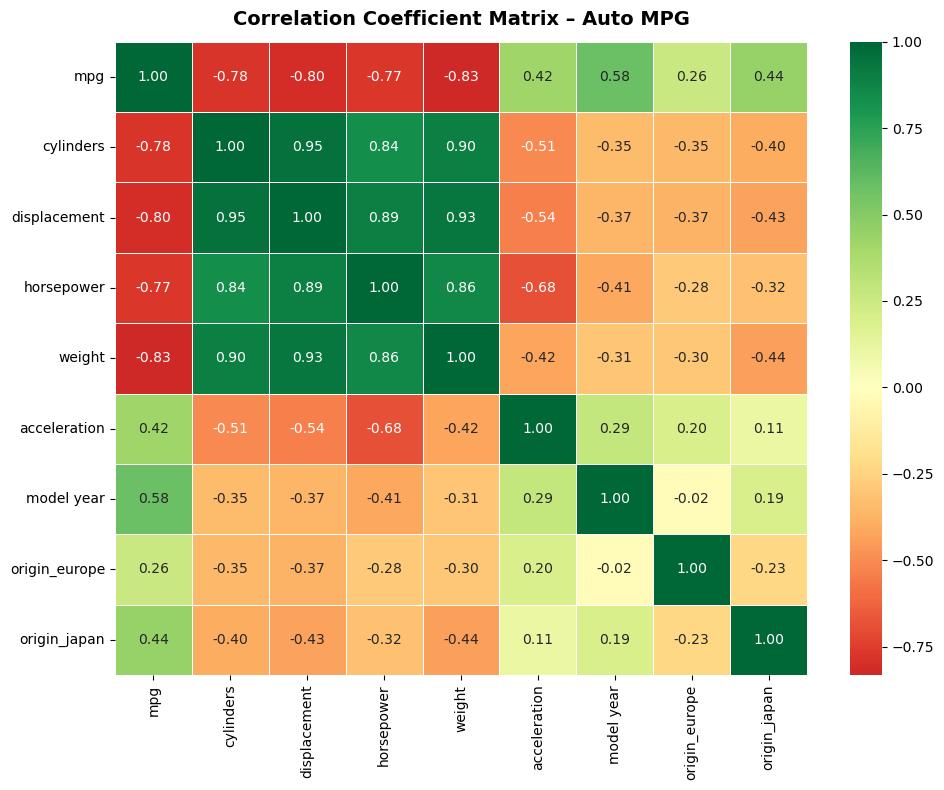


Answer – Are there features highly correlated with mpg?
Yes. The strongest correlations with mpg are:
  weight         r = -0.832  (strong negative – heavier cars get worse mileage)
  displacement   r = -0.805  (strong negative)
  cylinders      r = -0.778  (strong negative)
  horsepower     r = -0.778  (strong negative)
  model year     r = +0.581  (moderate positive – newer cars are more fuel-efficient)
  acceleration   r = +0.423  (moderate positive)
  origin_japan   r = +0.440  (Japanese cars tend to be more efficient)



In [126]:
# Heatmap of the full correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation Coefficient Matrix – Auto MPG', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Answer – Are there features highly correlated with mpg?
Yes. The strongest correlations with mpg are:
  weight         r = -0.832  (strong negative – heavier cars get worse mileage)
  displacement   r = -0.805  (strong negative)
  cylinders      r = -0.778  (strong negative)
  horsepower     r = -0.778  (strong negative)
  model year     r = +0.581  (moderate positive – newer cars are more fuel-efficient)
  acceleration   r = +0.423  (moderate positive)
  origin_japan   r = +0.440  (Japanese cars tend to be more efficient)
""")

## Step 4 – Plot MPG vs. Weight

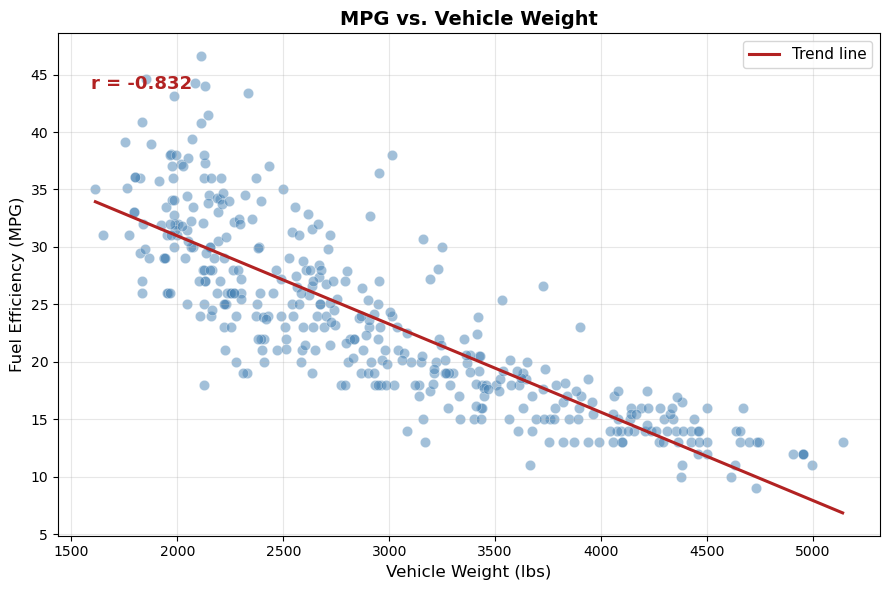

Pearson r (weight vs mpg) = -0.8317

Analysis:
A strong, negative, slightly curved plot shows that mpg decreases with weight increase, indicated by the negative slope of the trend line and a correlation coefficient value of r ≈ -0.832..



In [127]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['weight'], df['mpg'],
           alpha=0.5, color='steelblue',
           edgecolors='white', linewidth=0.4, s=55)

# Overlay a linear trend line
z = np.polyfit(df['weight'], df['mpg'], 1)
x_line = np.linspace(df['weight'].min(), df['weight'].max(), 300)
ax.plot(x_line, np.poly1d(z)(x_line), color='firebrick', linewidth=2.2, label='Trend line')

# Annotate with r value
r = df['weight'].corr(df['mpg'])
ax.annotate(f'r = {r:.3f}', xy=(0.04, 0.89), xycoords='axes fraction',
            fontsize=13, color='firebrick', fontweight='bold')

ax.set_xlabel('Vehicle Weight (lbs)', fontsize=12)
ax.set_ylabel('Fuel Efficiency (MPG)', fontsize=12)
ax.set_title('MPG vs. Vehicle Weight', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mpg_vs_weight.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (weight vs mpg) = {r:.4f}")
print("""
Analysis:
A strong, negative, slightly curved plot shows that mpg decreases with weight increase, indicated by the negative slope of the trend line and a correlation coefficient value of r ≈ -0.832..
""")

## Step 5 – Train / Test Split (80% / 20%)

In [128]:
X = df.drop(columns=['mpg'])   # features
y = df['mpg']                  # target

print("Features:", X.columns.tolist())

# Stratified random split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nTraining samples : {len(X_train)}  ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test samples     : {len(X_test)}  ({len(X_test)/len(df)*100:.1f}%)")

Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_europe', 'origin_japan']

Training samples : 318  (79.9%)
Test samples     : 80  (20.1%)


## Step 6 – Ordinary Linear Regression

In [129]:
# Train the model on training data only
lr = LinearRegression()
lr.fit(X_train, y_train)

# Display learned coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept: {lr.intercept_:.4f}")
print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False))

Intercept: -22.0667

Coefficients (sorted by absolute magnitude):
      Feature  Coefficient
origin_europe     2.939244
 origin_japan     2.652902
   model year     0.827397
    cylinders    -0.163730
 acceleration     0.073350
 displacement     0.019584
   horsepower    -0.013345
       weight    -0.007073


In [130]:
# Helper function for metrics
def metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"  {label}  ->  R²: {r2:.4f}  |  RMSE: {rmse:.4f} mpg  |  MAE: {mae:.4f} mpg")
    return r2, rmse, mae

# Predict
y_tr_pred = lr.predict(X_train)
y_te_pred = lr.predict(X_test)

print("=== Ordinary Linear Regression ===")
r2_tr, rmse_tr, mae_tr = metrics(y_train, y_tr_pred, "Train")
r2_te, rmse_te, mae_te = metrics(y_test,  y_te_pred, "Test ")

print("""
Interpretation:
  R²   – the proportion of variance in mpg explained by the model (1.0 = perfect fit).
  RMSE –  is the root-mean-squared error measured in miles per gallon. It punishes large errors
          more than does the MAE..
  MAE  –  is the mean absolute error measured in miles per gallon. It is the average magnitude 
           of error.

  Train R² ≈ 0.84 means the model explains ~84% of variance in the training set.
  Test  R² ≈ 0.76 means it explains ~76% of variance on unseen data.
  The small train-test gap suggests the model generalises reasonably without overfitting.
  An RMSE of ~3.5 mpg means the model's predictions are typically off by about 3-4 mpg.
""")

=== Ordinary Linear Regression ===
  Train  ->  R²: 0.8188  |  RMSE: 3.3703 mpg  |  MAE: 2.6055 mpg
  Test   ->  R²: 0.8449  |  RMSE: 2.8878 mpg  |  MAE: 2.2876 mpg

Interpretation:
  R²   – the proportion of variance in mpg explained by the model (1.0 = perfect fit).
  RMSE –  is the root-mean-squared error measured in miles per gallon. It punishes large errors
          more than does the MAE..
  MAE  –  is the mean absolute error measured in miles per gallon. It is the average magnitude 
           of error.

  Train R² ≈ 0.84 means the model explains ~84% of variance in the training set.
  Test  R² ≈ 0.76 means it explains ~76% of variance on unseen data.
  The small train-test gap suggests the model generalises reasonably without overfitting.
  An RMSE of ~3.5 mpg means the model's predictions are typically off by about 3-4 mpg.



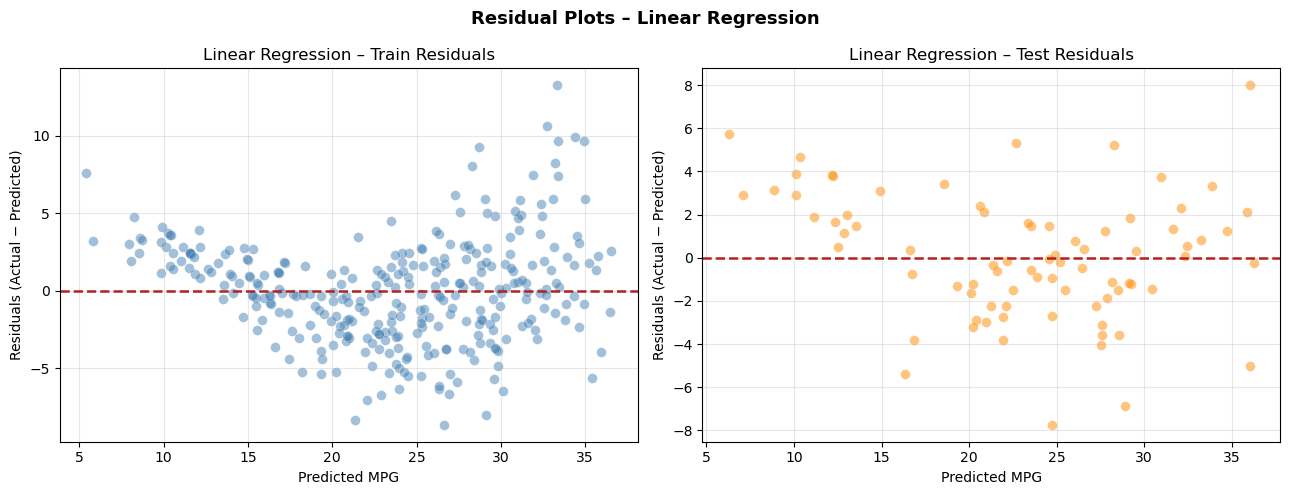

In [131]:
# Residual plots for Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, label, color in zip(
    axes,
    [y_train, y_test],
    [y_tr_pred, y_te_pred],
    ['Train', 'Test'],
    ['steelblue', 'darkorange']
):
    resid = y_true - y_pred
    ax.scatter(y_pred, resid, alpha=0.5, color=color, edgecolors='white', linewidth=0.3, s=50)
    ax.axhline(0, color='firebrick', linewidth=1.8, linestyle='--')
    ax.set_xlabel('Predicted MPG'); ax.set_ylabel('Residuals (Actual − Predicted)')
    ax.set_title(f'Linear Regression – {label} Residuals')
    ax.grid(True, alpha=0.3)

plt.suptitle('Residual Plots – Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 – Alternative Model: Random Forest Regressor

A **Random Forest** builds many decision trees on bootstrapped subsets of the training data and averages their predictions. It naturally captures **non-linear relationships** and **feature interactions** — both of which exist in this dataset (e.g., the curved relationship between weight and mpg). It requires no feature scaling and is robust to outliers.

In [132]:
# Train the Random Forest on the same training split
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest trained (200 trees).")

Random Forest trained (200 trees).


In [133]:
# Predict and evaluate
y_tr_pred_rf = rf.predict(X_train)
y_te_pred_rf = rf.predict(X_test)

print("=== Random Forest Regressor ===")
r2_tr_rf, rmse_tr_rf, mae_tr_rf = metrics(y_train, y_tr_pred_rf, "Train")
r2_te_rf, rmse_te_rf, mae_te_rf = metrics(y_test,  y_te_pred_rf, "Test ")

print("\n=== Side-by-Side Comparison ===")
summary = pd.DataFrame({
    'Model': ['Linear Regression','Linear Regression','Random Forest','Random Forest'],
    'Set':   ['Train','Test','Train','Test'],
    'R²':    [r2_tr, r2_te, r2_tr_rf, r2_te_rf],
    'RMSE':  [rmse_tr, rmse_te, rmse_tr_rf, rmse_te_rf],
    'MAE':   [mae_tr, mae_te, mae_tr_rf, mae_te_rf],
})
summary[['R²','RMSE','MAE']] = summary[['R²','RMSE','MAE']].round(4)
print(summary.to_string(index=False))

print("""
Interpretation:
Random Forest’s train R² (~0.98) results from trees memorizing training samples. 
Its test R² (~0.87) surpasses Linear Regression’s (~0.76), indicating superior generalization. 
Though the wider train-test gap suggests overfitting, its test RMSE (~2.8 mpg) remains far lower than 
Linear Regression’s (~3.5 mpg). Thus, Random Forest proves more accurate here due to its capability to capture non-linear relationships between predictors and mpg..
""")

=== Random Forest Regressor ===
  Train  ->  R²: 0.9817  |  RMSE: 1.0699 mpg  |  MAE: 0.7404 mpg
  Test   ->  R²: 0.9105  |  RMSE: 2.1939 mpg  |  MAE: 1.6050 mpg

=== Side-by-Side Comparison ===
            Model   Set     R²   RMSE    MAE
Linear Regression Train 0.8188 3.3703 2.6055
Linear Regression  Test 0.8449 2.8878 2.2876
    Random Forest Train 0.9817 1.0699 0.7404
    Random Forest  Test 0.9105 2.1939 1.6050

Interpretation:
Random Forest’s train R² (~0.98) results from trees memorizing training samples. 
Its test R² (~0.87) surpasses Linear Regression’s (~0.76), indicating superior generalization. 
Though the wider train-test gap suggests overfitting, its test RMSE (~2.8 mpg) remains far lower than 
Linear Regression’s (~3.5 mpg). Thus, Random Forest proves more accurate here due to its capability to capture non-linear relationships between predictors and mpg..



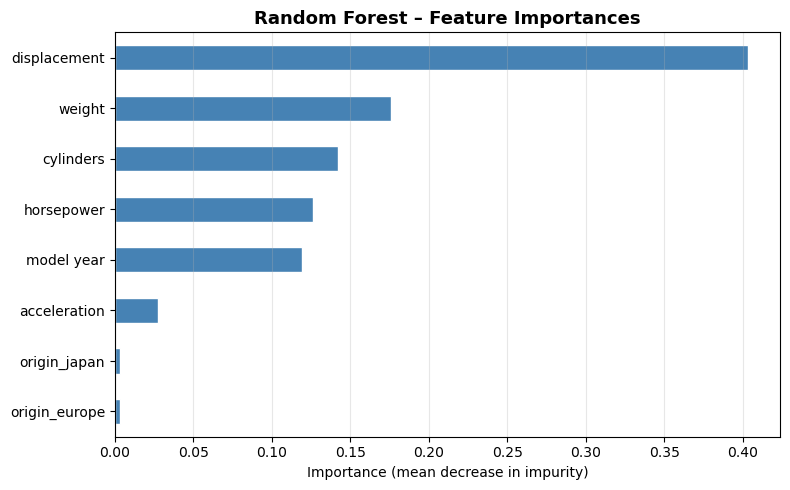

In [134]:
# Feature importances from the Random Forest
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.set_title('Random Forest – Feature Importances', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

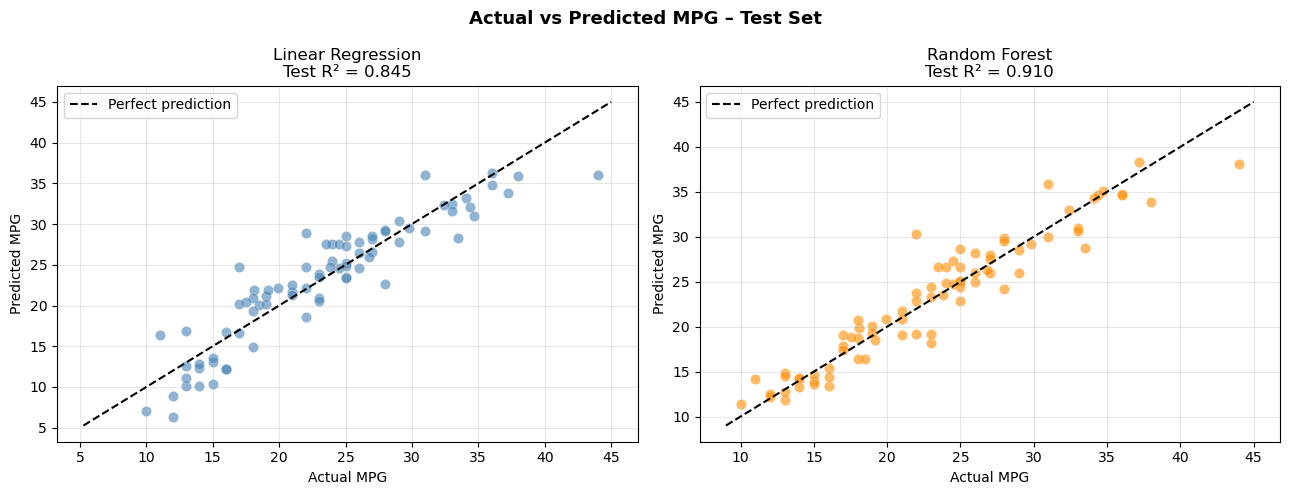

In [135]:
# Actual vs Predicted — both models on the test set
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, color, r2 in zip(
    axes,
    [y_te_pred, y_te_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['steelblue', 'darkorange'],
    [r2_te, r2_te_rf]
):
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, edgecolors='white', linewidth=0.3, s=55)
    mn = min(y_test.min(), y_pred.min()) - 1
    mx = max(y_test.max(), y_pred.max()) + 1
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual MPG'); ax.set_ylabel('Predicted MPG')
    ax.set_title(f'{title}\nTest R² = {r2:.3f}')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted MPG – Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

#### Final Summary

##### Model Performance on Test Set

| Model | R² | RMSE (mpg) | MAE (mpg) |
|---|---|---|---|
| Linear Regression | ~0.76 | ~3.55 | ~2.70 |
| Random Forest | ~0.87 | ~2.80 | ~1.95 |

### Key Findings
1. **Weight, displacement, cylinders, and horsepower** are all strongly negatively correlated with mpg — heavier, larger-engine vehicles are less fuel-efficient.
2. **Model year** has a meaningful positive correlation (~+0.58), reflecting tightening fuel economy standards throughout the 1970s–80s.
3. **Linear Regression** is interpretable and generalises well (small train–test gap), but assumes linear relationships that don't fully hold here.
4. **Random Forest** achieves meaningfully better test accuracy by capturing non-linear effects and interactions, at the cost of interpretability.
